# **HANDS ON: INTRODUCCIÓN A ESTADÍSTICA INFERENCIAL**

Una vez visto la presentación ***Introducción a la estadística inferencial***, se proporciona el siguiente ***colab*** para que **el alumnado pueda practicar** haciendo uso del lenguaje de programación ***python***.

De igual manera, se proporciona la **solución** de este notebook a través del siguiente [enlace](https://colab.research.google.com/drive/1wBQxgzbO4PV0meYNF_UCzhk7p6yC_xGu?usp=sharing).


## **PRUEBA DE HIPÓTESIS**

La **prueba de hipótesis** es un procedimiento formal dentro de la estadística inferencial que se usa para aceptar o rechazar una afirmación sobre un parámetro poblacional. Se basa en comparar dos hipótesis opuestas: la nula ($H_0$) y la alternativa ($H_1$).

***NOTA:*** *Se hará el uso de las bibliotecas de **Pandas**, **Seaborn** y **Scipy** para usar datasets precargados y operaciones estadísticas sin entrar a tanto detalle a las librerías mismas. Para ello, se explicará mas a detalle en el siguiente módulo.*

In [1]:
# Importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Importar dataset

df_tips = sns.load_dataset('tips')
df_tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


### **NIVEL DE SIGNIFICANCIA:**

Es el umbral de error que estamos dispuestos a aceptar. Comúnmente se utiliza **$\alpha = 0.01, 0.05, 0.1$** representando el 1%, 5%, y 10% de nivel de significancia correspondientemente.

* Si el **p-value < $\alpha$**: Rechazamos $H_0$ (Hay evidencia estadística).

* Si el **p-value > $\alpha$**: No podemos rechazar $H_0$ (No hay suficiente evidencia).

In [3]:
# Importar módulo
from scipy import stats

**Caso práctico:** ¿Existe una diferencia significativa entre la propina que dan los fumadores vs. los no fumadores?

* $H_0$: La media de propinas es igual para ambos grupos.

* $H_1$: La media de propinas es distinta entre fumadores y no fumadores.

In [4]:
# Separaración de grupos
propina_fumadores = df_tips[df_tips['smoker'] == 'Yes']['tip']
propina_no_fumadores = df_tips[df_tips['smoker']== 'No']['tip']

In [6]:
# Aplicar Prueba T de Student
t_stat, p_value = stats.ttest_ind(propina_fumadores, propina_no_fumadores)

print('t-statistic: ', round(t_stat, 4))
print('p-value: ', round(p_value, 4))

t-statistic:  0.0922
p-value:  0.9266


In [7]:
# Interpretar resultados
if p_value < 0.01:
    print('\nConclusión: Rechazamos la Hipótesis Nula')
    print('Existe una diferencia muy significativa entre las propinas de ambos grupos ')
elif p_value > 0.01 and p_value < 0.05:
     print('\nConclusión: Rechazamos la Hipótesis Nula')
     print('Existe una diferencia altamente significativa entre las propinas de ambos grupos ')
elif p_value > 0.05 and p_value < 0.1:
     print('\nConclusión: Rechazamos la Hipótesis Nula')
     print('Existe una diferencia moderamente significativa entre las propinas de ambos grupos ')
else:
     print('\nConclusión: No podemos rechazar la Hipótesis Nula')
     print('No hay evidendia suficiente para decir que las propinas son diferentes ')


Conclusión: No podemos rechazar la Hipótesis Nula
No hay evidendia suficiente para decir que las propinas son diferentes 


## **APRENDIZAJE ESTADÍSTICO**

El **aprendizaje estadístico** es un marco de trabajo que **combina la estadística y la computación** para construir **modelos predictivos o de clasificación** a partir de los datos. Es la base teórica de lo que hoy conocemos como Machine Learning.

### **REGRESIÓN LINEAL SIMPLE:**



Una **regresión lineal simple** es un método estadístico utilizado para modelar la relación entre una variable independiente, el cual actua como una **variable predictora**, y una variable dependiente que actua como una **variable objetivo**.

Su objetivo es encontrar una línea recta que mejor se ajuste a los datos para **predecir un valor objetivo en función del valor predictor**.

Una regresión lineal tiene la forma:

\begin{equation} \overline{y} = β\overline{x} + α  \, \, \, \equiv \, \, \, y = mx + b \end{equation}

Y su función de costo:

\begin{equation} c(x) = \frac{1}{n} Σ_{i=1}^n(\overline{y} - y_i)² \end{equation}

In [48]:
# Definir regresión lineal
x= df_tips['total_bill']
y=df_tips['tip']

linear_regression = np.polyfit(x,y, 1)
beta, alpha = linear_regression

print(f'y={beta}x +{alpha}')

y=0.10502451738435342x +0.9202696135546724


In [49]:
# Predicción de valores con regresión lineal
try:
   tb_pred_lr = int(input('agrega el valor del total de la cuenta que desea predecir la propina: ').strip())
   y_pred_lr = round(beta * tb_pred_lr + alpha, 2)
   print(f'la propina predicha para un total de ${tb_pred_lr} es de ${y_pred_lr}.')

except:
   print('Valor invalido, intente de nuevo porfavor :(')

la propina predicha para un total de $45 es de $5.65.


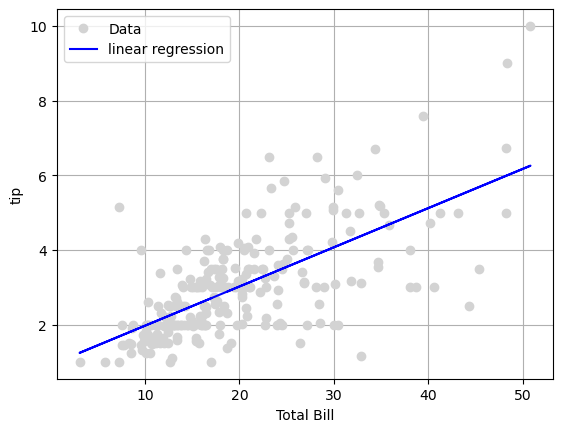

In [50]:
# Visualizar regresión lineal
plt.plot(x, y, 'o', color='lightgray', label ='Data')
plt.plot(x, beta * x + alpha, color ='blue', label='linear regression')
plt.xlabel('Total Bill')
plt.ylabel('tip')
plt.grid()
plt.legend()
plt.show()

In [127]:
# Iterar pérdida de la regresión lineal
num_iteraciones = 200
perdida= []

for i in range(num_iteraciones):
     y_pred = np.polyval(linear_regression, x[i])
     error = ((y - y_pred)**2).mean()
     perdida.append(error)

print(perdida)

[1.9928344447558304, 2.890782756972089, 1.9231351667023568, 2.073866197602785, 2.1611729661946733, 2.2407629971644627, 3.2451280647023486, 2.461707943950914, 2.155051278565445, 2.1830181135001543, 2.905423426677157, 4.547738612656033, 2.1168592059589115, 1.9268883286840883, 2.177524059445566, 1.942110612734541, 2.892867663126119, 2.0414147480921483, 1.9940724433927575, 1.914843568441012, 1.945012645002694, 1.909410984865738, 2.08450050011305, 6.158689234716453, 1.9066213064211528, 1.949674067446465, 2.360657103089329, 2.4620030185256123, 1.9470187398362095, 1.9068123540308575, 3.062287121109429, 1.929351921560588, 2.152961752406278, 1.915623671226294, 1.9509916911034424, 2.1081024970433786, 2.0398767293955706, 1.9965749130248167, 1.9198567170293273, 3.361304015807699, 2.061384516873853, 1.9662817201607334, 2.283564361197893, 3.0331184971670995, 3.1492454273960195, 1.9312922694716779, 1.9724961876191605, 3.6616645725480645, 2.75381995617644, 1.9402318890015664, 2.485731988747819, 2.9012

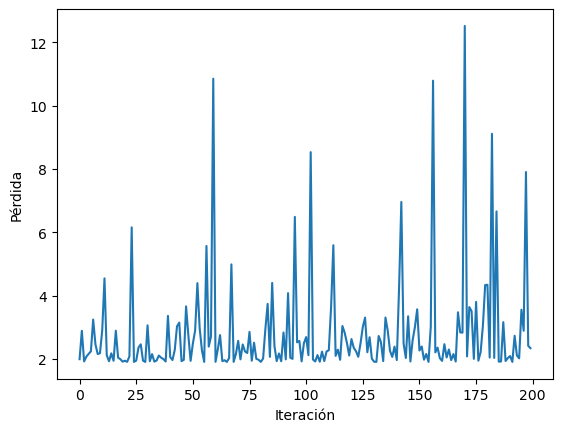

In [128]:
# Visualizar pérdida de la regresión lineal
plt.plot(perdida)
plt.xlabel('Iteración')
plt.ylabel('Pérdida')
plt.show()

### **DESCENSO DE GRADIENTE:**

El **descenso de gradiente** es un algoritmo de optimización ampliamente utilizado en el campo del aprendizaje automático y en la resolución numérica de problemas de optimización.

Su objetivo principal es encontrar el **mínimo de una función**, lo que es esencial en la optimización de modelos y la resolución de problemas matemáticos, para ajustar los parámetros de manera que la **función de costo se minimice**.

El descenso de gradiente tiene la forma:

\begin{equation} (ϴ_0, ϴ_1)_{i+1} = (ϴ_0, ϴ_1)_i - α * \frac{∂\,\,c(ϴ_0, ϴ_1)}{∂(ϴ_0, ϴ_1)} \, \, \,\, \, \,\, \, \, ; \, \, \,\, \, \,\, \, \, α \in (0, 1) \end{equation}

Donde su predicción:

\begin{equation} h_ϴ(x) = ϴ_1x + ϴ_0  \, \, \, \equiv \, \, \, y = mx + b \end{equation}


In [121]:
# Definir parámetros
tamano_paso = 0.001
theta_0 = 0
theta_1 = 0

perdida=[]

La función de costo tiene la forma:

\begin{equation} c(ϴ_0, ϴ_1) = \frac{1}{n} Σ_{i=1}^n(h_ϴ(x_i) - y_i)² \end{equation}

Al derivar función de costo:

*   Parámetro 1:

\begin{equation} \frac{∂}{∂(ϴ_0)}\ c(ϴ_0, ϴ_1) =  \frac{2}{n} Σ_{i=1}^n(h_ϴ(x_i) - y_i) \end{equation}


*   Paramétro 2:

\begin{equation} \frac{∂}{∂(ϴ_1)}\ c(ϴ_0, ϴ_1) =  \frac{2}{n} Σ_{i=1}^n(h_ϴ(x_i) - y_i)(x_i) \end{equation}

In [122]:
# Realizar algoritmo del descenso de gradiente
num_iteraciones = 100

for i in range(num_iteraciones):
    y_pred = theta_1 * x + theta_0
    error= ((y -y_pred)**2).mean()
    perdida.append(error)

    d_theta_0 = (2 /len(x)) * np.sum(y_pred -y)
    d_theta_1 = (2/len(x)) * np.sum((y_pred - y) * x)

    theta_0 = theta_0 - tamano_paso * d_theta_0
    theta_1 = theta_1 - tamano_paso * d_theta_1

print(f'y={theta_1}x +{theta_0}')

y=0.14222421840347957x +0.036159981060935556


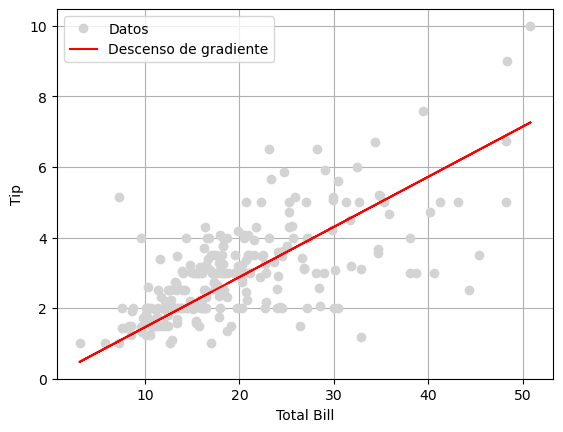

In [123]:
# Visualizar la regresión lineal por descenso de gradiente
plt.plot(x, y, 'o', color='lightgray', label = 'Datos')
plt.plot(x, theta_1 * x + theta_0, color ='red', label ='Descenso de gradiente')
plt.xlabel('Total Bill')
plt.ylabel('Tip')
plt.grid()
plt.legend()
plt.show()

In [124]:
# Predicción de valores con descenso de gradiente
try: 
   tb_pred_gd = int(input('Agrega el valor del total de la cuenta que deseas predecir la propina: ').strip())
   y_pred_gd = round(theta_1* tb_pred_gd + theta_0, 2 )

   print(f'La propina predicha para un total de ${tb_pred_gd} es de ${y_pred_gd}.')
except:
   print('Valor invalido, intente de nuevo porfavor :(')

#El descenso de gradiente se usa para minimizar la ecuación de minimos cuadrados? Es decir es un método para obtener la ecuación de regresión?
#Es decir no es un método alternativo a la regresión lineal sino un método para llegar a la regresion
#Descenso de gradiente es una regresión lineal con esteroides

La propina predicha para un total de $12 es de $1.74.


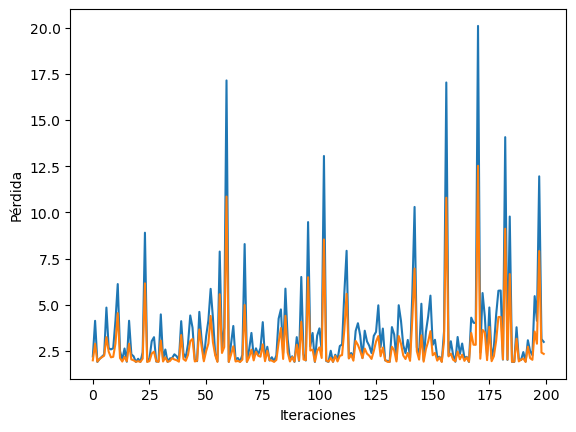

In [131]:
# Visualizar las pérdidas
num_iteraciones = 200
perdidas = []

for i in range(num_iteraciones):
    y_pred = theta_1 *x[i] + theta_0
    error = ((y-y_pred)**2).mean()
    perdidas.append(error)
plt.plot(perdidas)
plt.plot(perdida)
plt.xlabel('Iteraciones')
plt.ylabel('Pérdida')
plt.show()

#Azul Pérdida del decenso de gradiente
#Naranja Pérdida de la regresión

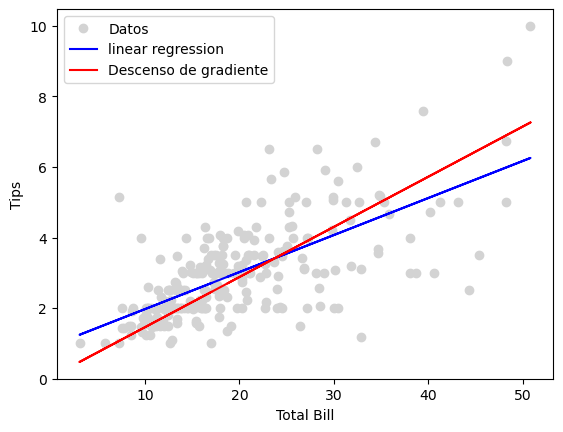

In [132]:
# Comparar las rectas obtenidas por los algoritmos
plt.plot(x, y, 'o', color='lightgray', label = 'Datos')
plt.plot(x, beta * x + alpha, color ='blue', label='linear regression')
plt.plot(x, theta_1 * x + theta_0, color ='red', label ='Descenso de gradiente')
plt.xlabel('Total Bill')
plt.ylabel('Tips')
plt.legend()
plt.show()

## **CHALLENGE: ANÁLISIS PREDICTIVO DE DATOS**

Una vez visto el ***Hands - On: Introducción a la estadística inferencial***, se presentan las siguientes actividades para que el alumnado pueda repasar y reforzar lo aprendido dentro de la clase.

Dentro de la siguiente dinámica, **se realizará un análisis de estadística inferecial** haciendo uso de **operaciones vectorizadas y visualización de datos** a través del **dataset taxis** proveniente de la librería de ***Seaborn***.

Donde los análisis a realizar son:

*   **Prueba de hipótesis**
*   **Aprendizaje estadístico**

**IMPORTANTE:** Para su revisión, **es indispensable que los apartados anteriores se encuentren llenados con el código visto durante la sesión.**

### **INSTRUCCIONES:**

**1. Importa las librerías:** Carga las bibliotecas de Numpy, Pandas, Seaborn y Matplotlib.pyplot.










In [16]:
# Importar librerías
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

**2. Importa el dataset de taxis:** Crea una variable denominada df_taxis donde se importe el dataset taxis.

In [17]:
# Importar dataset

df_taxis = sns.load_dataset('taxis')
df_taxis

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn


**3. Realiza una prueba de hipótesis:** Determina si existe una diferencia significativa entre la distancia recorrida de los taxis color amarillo y verde.

Donde:

   * H0: La media de distancia es igual para ambos colores.
   * H1: La media de distancia es distinta entre colores.

In [18]:
# Importar módulo
from scipy import stats

In [19]:
# Separación de grupos
taxi_amarillo = df_taxis[df_taxis['color']=='yellow']['distance']
taxi_verde = df_taxis[df_taxis['color']=='green']['distance']

In [20]:
# Aplicar Prueba T de Student
t_stat, p_value = stats.ttest_ind(taxi_amarillo, taxi_verde)

print('t-statistic: ',round(t_stat, 4))
print('p-value: ',round(p_value, 4))

t-statistic:  -3.406
p-value:  0.0007


In [21]:
# Interpretación automática

if p_value < 0.01:
    print('\nConclusión: Rechazámos la Hipótesis Nula.')
    print('Existe una diferencia muy significativa entre la distancia de ambos grupos')
elif p_value > 0.01 and p_value < 0.05:
    print('\nConclusión: Rechazámos la Hipótesis Nula.')
    print('Existe una diferencia altamente significativa entre la distancia de ambos grupos')
elif p_value > 0.05 and p_value < 0.10:
    print('\nConclusión: Rechazámos la Hipótesis Nula.')
    print('Existe una diferencia moderamente significativa entre la distancia de ambos grupos')
else:
    print('\nConclusión: No podemos rechazar la Hipótesis Nula.')
    print('No hay evidencia suficiente para decir que la distancia es diferente para los colores de los taxis')


Conclusión: Rechazámos la Hipótesis Nula.
Existe una diferencia muy significativa entre la distancia de ambos grupos


**4. Realiza un aprendizaje estadístico:**

   * Crea un modelo de regresión lineal simple para predecir el costo del viaje en función de la distancia recorrida.
   * Ajusta el modelo a través del algoritmo de optimización del descenso de gradiente.
   * Utiliza el modelo ajustado para realizar una predicción de cuánto costará un viaje de dado un valor agregado por el usuario en unidades de distancia.

In [22]:
# Definir regresión lineal
x = df_taxis['distance']
y= df_taxis['total']

linear_regression = np.polyfit(x, y, 1)
beta, alpha = linear_regression

print(f'y={beta}x + {alpha}')

y=3.2651658040714624x + 8.641918776697057


In [26]:
#Parametros
tamano_step = 0.001
theta_0 = 0
theta_1 = 0
perdidx = []

In [27]:
# Realizar algoritmo del descenso de gradiente
num_iteraciones = 100

for i in range(num_iteraciones):
    y_pred= theta_1 * x + theta_0
    error= ((y-y_pred)**2).mean()
    perdidx.append(error)

    d_theta_0 =(2/len(x)) * np.sum(y_pred-y)
    d_theta_1 =(2/len(x)) * np.sum((y_pred-y)*x)

    theta_0 =theta_0 - tamano_step * d_theta_0
    theta_1 = theta_1 - tamano_step * d_theta_1

print(f'y={theta_1}x +{theta_0}')

y=4.168174314857403x +1.4812777584944634


In [35]:
# Predicción de valores con descenso de gradiente
try:
   tb_pred_gr_taxi = float(input('Agregue la distancia que deseas predecir el total').strip())
   y_pred_gr_taxi = round(theta_1 * tb_pred_gr_taxi + theta_0, 2)

   print(f'El total predicho para una distancia de {tb_pred_gr_taxi} es de ${y_pred_gr_taxi}')

except:
    print('Intente nuevamente con un número')

El total predicho para una distancia de 0.8 es de $4.82


**5. Visualiza los resultados:**

   * Grafica las líneas de las regresiones para comparar entre la regresión lineal simple y el algoritmo de optimización.
   * Grafica la función de costo resultante del ajuste con el algoritmo de optimización.

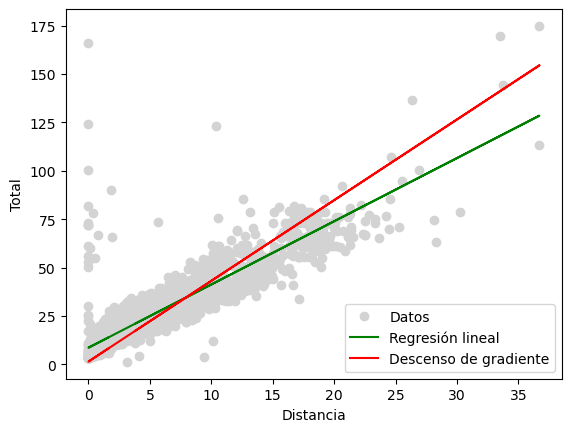

In [38]:
# Visualizar regresiones
plt.plot(x, y , 'o', color ='lightgrey', label = 'Datos')
plt.plot(x, beta * x + alpha, color='green', label='Regresión lineal')
plt.plot(x, theta_1 * x + theta_0, color='red', label='Descenso de gradiente')
plt.xlabel('Distancia')
plt.ylabel('Total')
plt.legend()
plt.show()

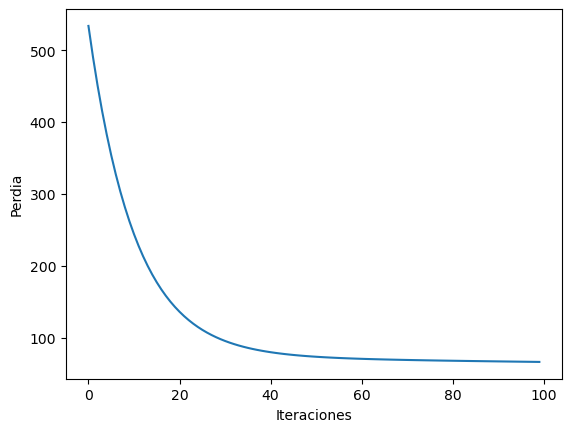

In [37]:
# Visualizar función de costo
plt.plot(perdidx)
plt.xlabel('Iteraciones')
plt.ylabel('Perdia')
plt.show()